## Introduction to Data Science

#### University of Redlands - DATA 101
#### Prof: Joanna Bieri [joanna_bieri@redlands.edu](mailto:joanna_bieri@redlands.edu)
#### [Class Website: data101.joannabieri.com](https://joannabieri.com/data101.html)

---------------------------------------
# Homework Day 16
---------------------------------------

GOALS:

1. Work to understand when a linear model vs. non-linear model is a good choice.
2. Practice plotting residuals and regression lines.
3. Do an analysis using non-linear regression.


----------------------------------------------------------

This homework has **2 Questions** and **3 Exercises**

## Important Information

- Email: [joanna_bieri@redlands.edu](mailto:joanna_bieri@redlands.edu)
- Office Hours: Duke 209 <a href="https://joannabieri.com/schedule.html"> Click Here for Joanna's Schedule</a>


## Announcements

**Come to Lab!** If you need help we are here to help!



In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

# This stops a few warning messages from showing
pd.options.mode.chained_assignment = None 
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Machine Learning Packages
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression 

## Paris Paintings Data - Load the data

To explore the ideas of modeling data we will use the Paris Paintings dataset.

- Source: Printed catalogs of 28 auction sales in Paris, 1764 - 1780 (Historical Data)
- Data curators Sandra van Ginhoven and Hilary Coe Cronheim (who were PhD students in the Duke Art, Law, and Markets Initiative at the time of putting together this dataset) translated and tabulated the catalogs
-  3393 paintings, their prices, and descriptive details from sales catalogs over 60 variables

[Variables in Paris Paintings Data](https://www2.stat.duke.edu/~cr173/Sta112_Fa16/data/paris_paintings.html)

This lab follows the Data Science in a Box units "Unit 4 - Deck 3: Modeling nonlinear relationships " by Mine Çetinkaya-Rundel. It has been updated for our class and translated to Python by Joanna Bieri.

In [4]:
file_location = 'https://joannabieri.com/introdatascience/data/paris-paintings.csv'
DF_raw_paintings = pd.read_csv(file_location,na_filter=False)

In [5]:
DF_raw_paintings

,name,sale,lot,position,dealer,year,origin_author,origin_cat,school_pntg,diff_origin,...,peasant,othgenre,singlefig,portrait,still_life,discauth,history,allegory,pastorale,other
0,L1764-2,L1764,2,0.032787,L,1764,F,O,F,1,...,0,0,0,0,0,0,0,0,0,0
1,L1764-3,L1764,3,0.049180,L,1764,I,O,I,1,...,0,1,0,0,0,0,0,0,0,0
2,L1764-4,L1764,4,0.065574,L,1764,X,O,D/FL,1,...,0,0,0,0,0,0,0,0,0,0
3,L1764-5a,L1764,5,0.081967,L,1764,F,O,F,1,...,0,0,0,0,0,0,0,0,0,0
4,L1764-5b,L1764,5,0.081967,L,1764,F,O,F,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3388,R1764-498,R1764,498,0.992032,R,1764,F,O,F,1,...,0,0,0,0,0,0,0,0,0,0
3389,R1764-499,R1764,499,0.994024,R,1764,F,O,F,1,...,0,0,0,0,0,0,0,0,0,0
3390,R1764-500,R1764,500,0.996016,R,1764,F,O,F,1,...,0,0,0,0,0,0,0,0,0,0
3391,R1764-502a,R1764,502,1.000000,R,1764,F,O,F,1,...,0,0,1,0,0,0,0,0,0,0


In [6]:
# Make a copy of the data that we can start working on
DF = DF_raw_paintings.copy()

# Do something about all those different NaNs
DF.replace('',np.nan,inplace=True)
DF.replace('n/a',np.nan,inplace=True)
DF.replace('NaN',np.nan,inplace=True)

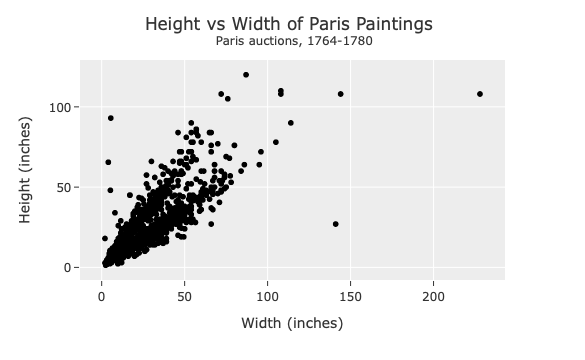

In [7]:
# Update the types - these should be floats
DF['Height_in'] = DF['Height_in'].apply(lambda x: float(x))
DF['Width_in'] = DF['Width_in'].apply(lambda x: float(x))

fig = px.scatter(DF,x='Width_in',y="Height_in",color_discrete_sequence=['black'])

fig.update_layout(template="ggplot2",
                  title='Height vs Width of Paris Paintings <br><sup> Paris auctions, 1764-1780</sup>',
                  title_x=0.5,
                  xaxis_title="Width (inches)",
                  yaxis_title="Height (inches)")

fig.show()

In [8]:
# Get the data I want to model
my_columns = ['Surface','price']
DF_model = DF[my_columns].copy()

# Check out the NaNs

# How many Nans
print('Number of NaNs:')
print(DF_model.isna().sum())
print('----------------------')

# What percent of the data is this?
print('Percent total NaNs:')
print(DF_model.isna().sum().sum()/len(DF))
print('----------------------')

# I am going to drop these! This is a choice!
DF_model.dropna(inplace=True)
print('Number of NaNs after drop:')
print(DF_model.isna().sum().sum())
print('----------------------')

Number of NaNs:
Surface    176
price        0
dtype: int64
----------------------
Percent total NaNs:
0.051871500147362214
----------------------
Number of NaNs after drop:
0
----------------------


In [9]:
# Create the inputs X (explanatory variable) and the outputs y (response variable)

X = DF_model['price'].values.reshape(-1, 1)
y = DF_model['Surface'].values
# Create linear regression object - a random straight line
LM = LinearRegression()

# Train the model using the data
LM.fit(X, y)

LinearRegression()

In [10]:
my_cols = ['Surface', 'price']
DF[my_cols].dtypes

Surface     object
price      float64
dtype: object

In [11]:
DF['Surface'] = DF['Surface'].apply(lambda x: float(x))
DF['price'] = DF['price'].apply(lambda x: float(x))
DF[my_cols].dtypes

Surface    float64
price      float64
dtype: object

In [12]:
# The coefficient is the slope
print(LM.coef_)
print(LM.intercept_)

print(LM.score(X,y))

[0.05937907]
583.9027502735738
0.011141075251450694


## Explore Linearity

Fit a model for Price as a function of size. Let's redo that analysis except this time focus only on paintings with area of less than 10,000 inches squared.

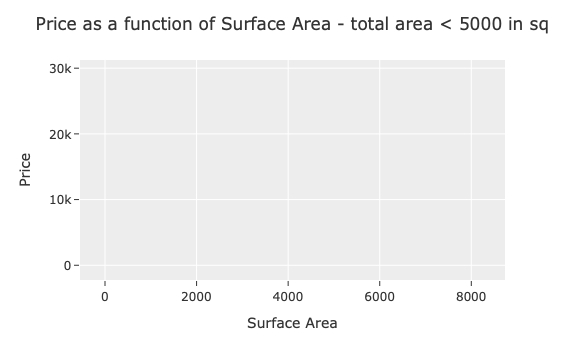

Model Score:
0.014875957473786783


In [13]:
#| code-fold: true
#| code-summary: "Answer to Exercise 2 Day 15 for paintings < 10000 in^2"

# Get the columns I care about
my_columns = ['Surface','price']
DF_model2 = DF[my_columns]

# Do some preprocessing - drop NA and make the Surface variable a float
DF_model2.dropna(inplace=True)
DF_model2['Surface'] = DF_model2['Surface'].apply(lambda x: float(x))

# Mask the data for surface area less than 10,000
mask = DF_model2['Surface'] <= 10_000
DF_model2 = DF_model2[mask]

# Make a Scatter plot
fig = px.scatter(DF_model2,
                 x='Surface',
                 y='price',
                 color_discrete_sequence=['black'],
                 opacity=0.2)

fig.update_layout(template="ggplot2",
                  title='Price as a function of Surface Area - total area < 5000 in sq',
                  title_x=0.5,
                  xaxis_title='Surface Area',
                  yaxis_title='Price')


fig.show()

# Create the X and y variables for Linear Regression
X = DF_model2['Surface'].values.reshape(-1,1)
y = DF_model2['price'].values

# Create linear regression object - a random straight line
LM = LinearRegression()
# Train the model using the data
LM.fit(X, y)

# The score from my model
print('Model Score:')
print(LM.score(X,y))

**Exercise 1** Create a Residual plot for the model above.

1. Get the predictions - store these in a column in the data frame

```{python}
LM.predict(X)
```

2. Calculate the residuals - store these in a column in the data frame
```{python}
'Residual' = 'Real Value in the Data' - 'Value Predicted by LM'
```

3. Plot the result
```{python}
px.scatter(df,x='Value Predicted by LM',y='Residual')
```


See if you can recreate the plot shown in the lecture.

In [14]:
DF_model2['price_predicted'] = LM.predict(X)

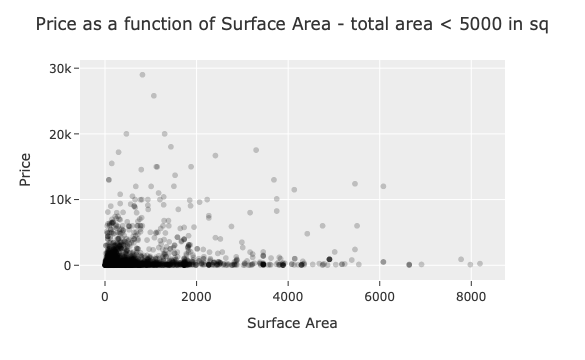

Model Score:
0.014875957473786783


In [15]:
# Get the columns I care about
my_columns = ['Surface','price']
DF_model2 = DF[my_columns]

# Do some preprocessing - drop NA and make the Surface variable a float
DF_model2.dropna(inplace=True)
DF_model2['Surface'] = DF_model2['Surface'].apply(lambda x: float(x))

# Mask the data for surface area less than 10,000
mask = DF_model2['Surface'] <= 10_000
DF_model2 = DF_model2[mask]

# Make a Scatter plot
fig = px.scatter(DF_model2,
                 x='Surface',
                 y='price',
                 color_discrete_sequence=['black'],
                 opacity=0.2)

fig.update_layout(template="ggplot2",
                  title='Price as a function of Surface Area - total area < 5000 in sq',
                  title_x=0.5,
                  xaxis_title='Surface Area',
                  yaxis_title='Price')


fig.show()

# Create the X and y variables for Linear Regression
X = DF_model2['Surface'].values.reshape(-1,1)
y = DF_model2['price'].values

# Create linear regression object - a random straight line
LM = LinearRegression()
# Train the model using the data
LM.fit(X, y)

# The score from my model
print('Model Score:')
print(LM.score(X,y))

In [16]:
DF_model2['price_predicted'] = LM.predict(X)
DF_model2['residual'] = DF_model2['price']-DF_model2['price_predicted']
DF_model2

,Surface,price,price_predicted,residual
0,1091.5,360.0,904.234443,-544.234443
1,252.0,6.0,683.985984,-677.985984
2,208.0,12.0,672.442289,-660.442289
3,252.0,6.0,683.985984,-677.985984
4,252.0,6.0,683.985984,-677.985984
...,...,...,...,...
3388,387.0,18.0,719.404140,-701.404140
3389,214.5,25.0,674.147607,-649.147607
3390,720.0,80.0,806.768925,-726.768925
3391,621.0,5.0,780.795610,-775.795610


In [17]:
my_cols = ['Surface','price','residual','price_predicted']
DF_model2[my_cols].dtypes

Surface            float64
price              float64
residual           float64
price_predicted    float64
dtype: object

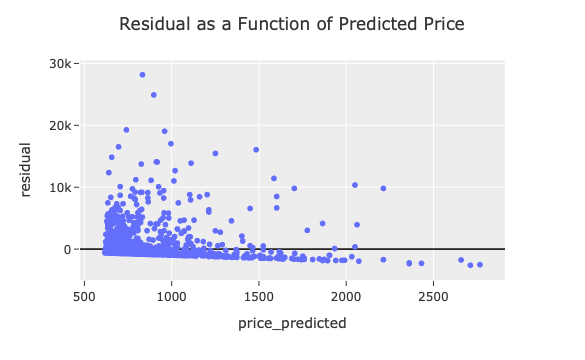

In [18]:
fig = px.scatter(DF_model2,x='price_predicted',y='residual')

# Update layout to show axis line at y=0
fig.update_layout(
    yaxis={'zeroline':True, 'zerolinewidth':1.5, 'zerolinecolor':"black"}
)

fig.update_layout(template="ggplot2",
                  title='Residual as a Function of Predicted Price',
                  title_x=0.5
                 )

fig.show()

**Q1** What do you see here? Does this residual data seem uniformly distributed?


not too much, the linear prediction does not capture the pattern in the data

## From Lecture - Consider the skew in the data

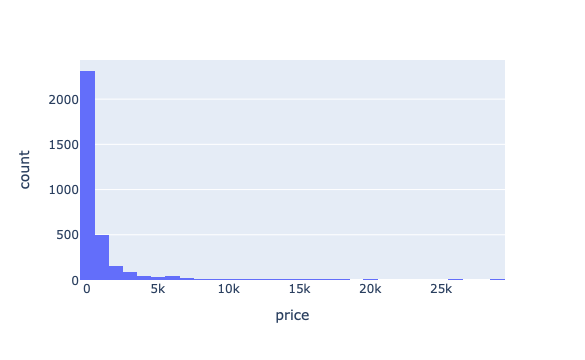

In [19]:
# Plot a histogram - notice that it is very skewed
fig = px.histogram(DF_model2,x='price',nbins =30)
fig.show()

In [20]:
# Us numpy to take the natural log of the data - removing the exponential decay
DF_model2['log_price'] = np.log(DF_model2['price'])

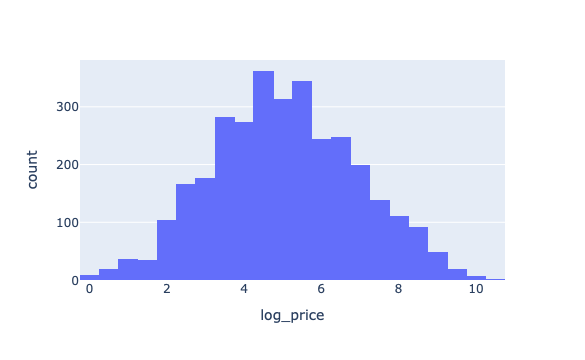

In [21]:
# Plot a histogram of the log(price) - notice we have removed the skew
fig = px.histogram(DF_model2,x='log_price',nbins =30)

fig.show()

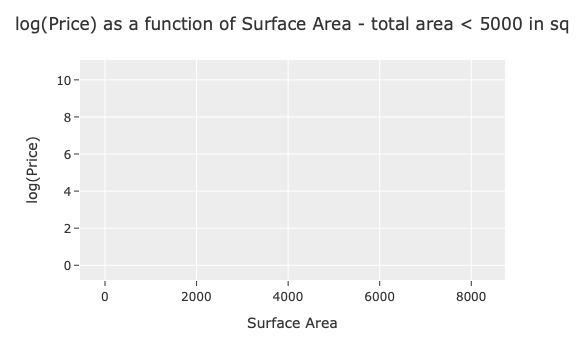

In [22]:
# Look at the scatter plot of the log(price)
fig = px.scatter(DF_model2,
                 x='Surface',
                 y='log_price',
                 color_discrete_sequence=['black'],
                 opacity=0.2,
                 trendline='ols')

fig.update_layout(template="ggplot2",
                  title='log(Price) as a function of Surface Area - total area < 5000 in sq',
                  title_x=0.5,
                  xaxis_title='Surface Area',
                  yaxis_title='log(Price)')


fig.show()

**Q2** What is different about the histogram and the scatter plots after taking the natural log?

the histogram gets more distributed accross the values and no longer have the skewness and the scatter plot does not have much of a linear relationship

**Exercise 2:** Redo the linear regression analysis except this time use the log_price.

- Find the linear regression model (LM)
- Calculate the residual
- Plot the Residual as a function of the predicted log price
- Plot a scatter plot of the data with the linear regression line added.

*HINT* You can see my results in the lecture notes!

In [23]:
# Us numpy to take the natural log of the data - removing the exponential decay
DF_model2['log_price'] = np.log(DF_model2['price'])

In [24]:
# Create the inputs X (explanatory variable) and the outputs y (response variable)

X = DF_model2['Surface'].values.reshape(-1, 1)
y = DF_model2['log_price'].values
# Create linear regression object - a random straight line
LM = LinearRegression()

# Train the model using the data
LM.fit(X, y)

LinearRegression()

In [25]:
# The coefficient is the slope
print(LM.coef_)
print(LM.intercept_)

print(LM.score(X,y))

[0.0002376]
4.911544880415433
0.013268243020669424


In [26]:
DF_model2['log_price_predicted'] = LM.predict(X)
DF_model2['residual'] = DF_model2['log_price']-DF_model2['log_price_predicted']
DF_model2

,Surface,price,price_predicted,residual,log_price,log_price_predicted
0,1091.5,360.0,904.234443,0.715222,5.886104,5.170882
1,252.0,6.0,683.985984,-3.179660,1.791759,4.971419
2,208.0,12.0,672.442289,-2.476058,2.484907,4.960965
3,252.0,6.0,683.985984,-3.179660,1.791759,4.971419
4,252.0,6.0,683.985984,-3.179660,1.791759,4.971419
...,...,...,...,...,...,...
3388,387.0,18.0,719.404140,-2.113123,2.890372,5.003495
3389,214.5,25.0,674.147607,-1.743634,3.218876,4.962509
3390,720.0,80.0,806.768925,-0.700588,4.382027,5.082615
3391,621.0,5.0,780.795610,-3.449655,1.609438,5.059093


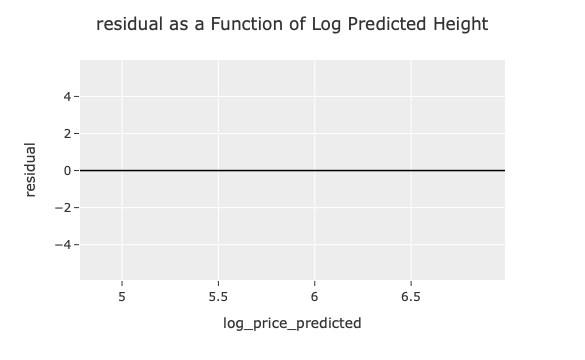

In [27]:
fig = px.scatter(DF_model2,x='log_price_predicted',y='residual')

# Update layout to show axis line at y=0
fig.update_layout(
    yaxis={'zeroline':True, 'zerolinewidth':1.5, 'zerolinecolor':"black"}
)

fig.update_layout(template="ggplot2",
                  title='residual as a Function of Log Predicted Height',
                  title_x=0.5
                 )
fig.show()

In [28]:
DF_model2

,Surface,price,price_predicted,residual,log_price,log_price_predicted
0,1091.5,360.0,904.234443,0.715222,5.886104,5.170882
1,252.0,6.0,683.985984,-3.179660,1.791759,4.971419
2,208.0,12.0,672.442289,-2.476058,2.484907,4.960965
3,252.0,6.0,683.985984,-3.179660,1.791759,4.971419
4,252.0,6.0,683.985984,-3.179660,1.791759,4.971419
...,...,...,...,...,...,...
3388,387.0,18.0,719.404140,-2.113123,2.890372,5.003495
3389,214.5,25.0,674.147607,-1.743634,3.218876,4.962509
3390,720.0,80.0,806.768925,-0.700588,4.382027,5.082615
3391,621.0,5.0,780.795610,-3.449655,1.609438,5.059093


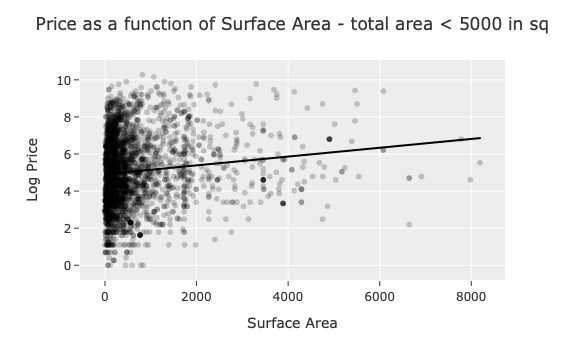

Model Score:
0.013268243020669424


In [29]:
# Get the columns I care about
my_columns = ['Surface','log_price']
DF_model3 = DF_model2[my_columns]

# Do some preprocessing - drop NA and make the Surface variable a float
DF_model3.dropna(inplace=True)
DF_model3['Surface'] = DF_model3['Surface'].apply(lambda x: float(x))

# Mask the data for surface area less than 10,000
mask = DF_model3['Surface'] <= 10_000
DF_model3 = DF_model2[mask]

# Make a Scatter plot
fig = px.scatter(DF_model3,
                 x='Surface',
                 y='log_price',
                 color_discrete_sequence=['black'],
                 opacity=0.2,
                trendline='ols')

fig.update_layout(template="ggplot2",
                  title='Price as a function of Surface Area - total area < 5000 in sq',
                  title_x=0.5,
                  xaxis_title='Surface Area',
                  yaxis_title='Log Price')


fig.show()

# Create the X and y variables for Linear Regression
X = DF_model3['Surface'].values.reshape(-1,1)
y = DF_model3['log_price'].values

# Create linear regression object - a random straight line
LM = LinearRegression()
# Train the model using the data
LM.fit(X, y)
px.scatter(DF_model3,x='log_price_predicted',y='residual',trendline='ols')
plt.show()
# The score from my model
print('Model Score:')
print(LM.score(X,y))

In [30]:
# px.scatter?

### What did we learn...

What is the model telling me?

$$ \hat{\log(price)} = 4.912 + 0.00024(Surface Area)$$

so we can calculate (see the lecture for details!)

$$ (SA+1) \sim 1.0002400288023041 * SA$$

This tells us that increase the area of the painting by one square inch increases the price by a factor of 1.0002400288023041 or about 0.024%.

There is a small positive increase in the price as the surface area increases, on average. 

Can we predict the price using the surface area? Look at LM.score(X,y)...

It does not appear that our logistic regression is a good predictor of the price. Even though it looks like we captured a good linear relationship, we do not have a good predictor. The scatter is still very large!

BUT - we are still able to see a linear trend in the model. There is a relationship here even though the data is very noisy!

**Exercise 3** Redo the full analysis except this time try using just height to predict price.

- Do a standard linear regression of the height vs. the price (without log) discuss the results. This should include a plot of the residuals and a plot showing the linear fit. You should also talk about what the score, intercept and coefficient of the model are telling you. EG. As the height increases by 1in the price.....
- Do a linear regression of the height vs. log_price and discuss the results. This should include a plot of the residuals and a plot showing the linear fit. You should also talk about what the score, intercept and coefficient of the model are telling you. EG. As the height increases by 1in the price..... Remember in this case you have to use the rules of logs and exponents to interpret the results.

Which of these models do you think is doing a better job of capturing the functional relationships in the price vs height data? Why?

In [31]:
my_columns = ['Height_in','price']
DF_model4 = DF[my_columns]
DF_model4

,Height_in,price
0,37.0,360.0
1,18.0,6.0
2,13.0,12.0
3,14.0,6.0
4,14.0,6.0
...,...,...
3388,18.0,18.0
3389,13.0,25.0
3390,24.0,80.0
3391,27.0,5.0


In [32]:
# my_columns = ['Height_in','price']
# DF_model4 = DF[my_columns].copy

# Check out the NaNs

# How many Nans
print('Number of NaNs:')
print(DF_model4.isna().sum())
print('----------------------')

# What percent of the data is this?
print('Percent total NaNs:')
print(DF_model4.isna().sum().sum()/len(DF))
print('----------------------')

# I am going to drop these! This is a choice!
DF_model4.dropna(inplace=True)
print('Number of NaNs after drop:')
print(DF_model4.isna().sum().sum())
print('----------------------')

Number of NaNs:
Height_in    252
price          0
dtype: int64
----------------------
Percent total NaNs:
0.07427055702917772
----------------------
Number of NaNs after drop:
0
----------------------


In [33]:
DF_model4

,Height_in,price
0,37.0,360.0
1,18.0,6.0
2,13.0,12.0
3,14.0,6.0
4,14.0,6.0
...,...,...
3388,18.0,18.0
3389,13.0,25.0
3390,24.0,80.0
3391,27.0,5.0


In [34]:
DF['Height_in'] = DF['Height_in'].apply(lambda x: float(x))

X = DF_model4['Height_in'].values.reshape(-1, 1)
y = DF_model4['price'].values
# Create linear regression object - a random straight line
LM = LinearRegression()

# Train the model using the data
LM.fit(X, y)

LinearRegression()

In [35]:
print(LM.coef_)
print(LM.intercept_)

print(LM.score(X,y))

[15.07549869]
485.3546427150767
0.01276057594959179


In [36]:
DF_model4['price_predicted'] = LM.predict(X)
DF_model4['residual3'] = DF_model2['price']-DF_model2['price_predicted']
DF_model4

,Height_in,price,price_predicted,residual3
0,37.0,360.0,1043.148094,-544.234443
1,18.0,6.0,756.713619,-677.985984
2,13.0,12.0,681.336126,-660.442289
3,14.0,6.0,696.411624,-677.985984
4,14.0,6.0,696.411624,-677.985984
...,...,...,...,...
3388,18.0,18.0,756.713619,-701.404140
3389,13.0,25.0,681.336126,-649.147607
3390,24.0,80.0,847.166611,-726.768925
3391,27.0,5.0,892.393107,-775.795610


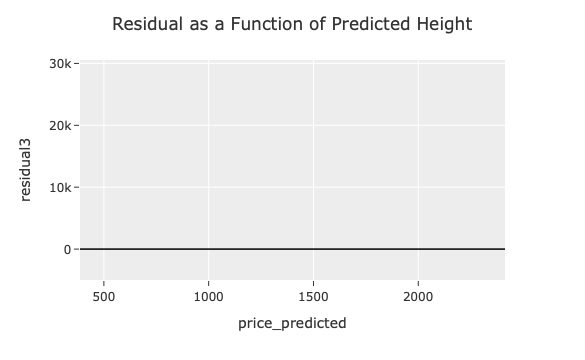

In [37]:
fig = px.scatter(DF_model4,x='price_predicted',y='residual3')

# Update layout to show axis line at y=0
fig.update_layout(
    yaxis={'zeroline':True, 'zerolinewidth':1.5, 'zerolinecolor':"black"}
)

fig.update_layout(template="ggplot2",
                  title='Residual as a Function of Predicted Height',
                  title_x=0.5
                 )
fig.show()

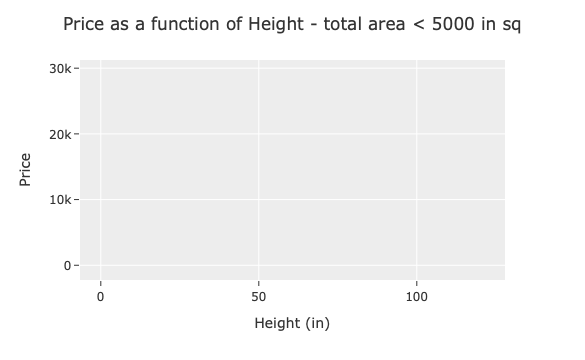

Model Score:
0.01276057594959179


In [38]:
# Get the columns I care about
my_columns = ['Height_in','price']
DF_model5 = DF_model4[my_columns]

# Do some preprocessing - drop NA and make the Surface variable a float
DF_model5.dropna(inplace=True)
DF_model5['Height_in'] = DF_model5['Height_in'].apply(lambda x: float(x))

# Mask the data for surface area less than 10,000
mask = DF_model5['Height_in'] <= 10_000
DF_model5 = DF_model4[mask]

# Make a Scatter plot
fig = px.scatter(DF_model5,
                 x='Height_in',
                 y='price',
                 color_discrete_sequence=['black'],
                 opacity=0.2,
                 trendline='ols')

fig.update_layout(template="ggplot2",
                  title='Price as a function of Height - total area < 5000 in sq',
                  title_x=0.5,
                  xaxis_title='Height (in)',
                  yaxis_title='Price')


fig.show()

# Create the X and y variables for Linear Regression
X = DF_model5['Height_in'].values.reshape(-1,1)
y = DF_model5['price'].values

# Create linear regression object - a random straight line
LM = LinearRegression()
# Train the model using the data
LM.fit(X, y)
px.scatter(DF_model5,x='price_predicted',y='residual3')
# The score from my model
print('Model Score:')
print(LM.score(X,y))

As the height increases by 1 in, the price increases by $15.08, according to the trendline. a low model score tells me that there is very little correlation between height and price and that the data is not linear.

In [39]:
my_columns = ['Height_in','price']
DF_model6 = DF[my_columns]
DF_model6['log_price'] = np.log(DF_model6['price'])
DF_model6

,Height_in,price,log_price
0,37.0,360.0,5.886104
1,18.0,6.0,1.791759
2,13.0,12.0,2.484907
3,14.0,6.0,1.791759
4,14.0,6.0,1.791759
...,...,...,...
3388,18.0,18.0,2.890372
3389,13.0,25.0,3.218876
3390,24.0,80.0,4.382027
3391,27.0,5.0,1.609438


In [40]:
# How many Nans
print('Number of NaNs:')
print(DF_model6.isna().sum())
print('----------------------')

# What percent of the data is this?
print('Percent total NaNs:')
print(DF_model6.isna().sum().sum()/len(DF))
print('----------------------')

# I am going to drop these! This is a choice!
DF_model6.dropna(inplace=True)
print('Number of NaNs after drop:')
print(DF_model6.isna().sum().sum())
print('----------------------')

Number of NaNs:
Height_in    252
price          0
log_price      0
dtype: int64
----------------------
Percent total NaNs:
0.07427055702917772
----------------------
Number of NaNs after drop:
0
----------------------


In [41]:
DF['Height_in'] = DF['Height_in'].apply(lambda x: float(x))

X = DF_model6['Height_in'].values.reshape(-1, 1)
y = DF_model6['log_price'].values
# Create linear regression object - a random straight line
LM = LinearRegression()

# Train the model using the data
LM.fit(X, y)

LinearRegression()

In [42]:
print(LM.coef_)
print(LM.intercept_)

print(LM.score(X,y))

[0.01036213]
4.868389335057932
0.006754700790331358


In [43]:
DF_model6['log_price_predicted'] = LM.predict(X)
DF_model6['residual4'] = DF_model3['log_price']-DF_model3['log_price_predicted']
DF_model6

,Height_in,price,log_price,log_price_predicted,residual4
0,37.0,360.0,5.886104,5.251788,0.715222
1,18.0,6.0,1.791759,5.054908,-3.179660
2,13.0,12.0,2.484907,5.003097,-2.476058
3,14.0,6.0,1.791759,5.013459,-3.179660
4,14.0,6.0,1.791759,5.013459,-3.179660
...,...,...,...,...,...
3388,18.0,18.0,2.890372,5.054908,-2.113123
3389,13.0,25.0,3.218876,5.003097,-1.743634
3390,24.0,80.0,4.382027,5.117080,-0.700588
3391,27.0,5.0,1.609438,5.148167,-3.449655


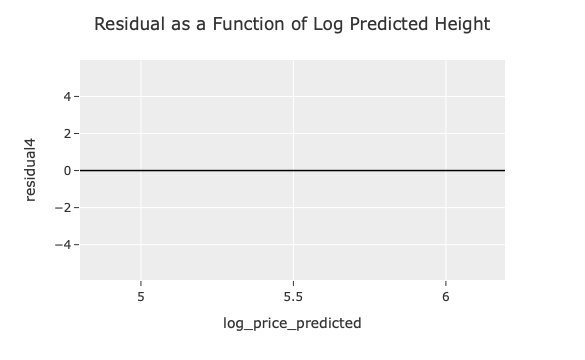

Model Score:
0.006754700790331358


In [46]:
fig = px.scatter(DF_model6,x='log_price_predicted',y='residual4')

# Update layout to show axis line at y=0
fig.update_layout(
    yaxis={'zeroline':True, 'zerolinewidth':1.5, 'zerolinecolor':"black"}
)

fig.update_layout(template="ggplot2",
                  title='Residual as a Function of Log Predicted Height',
                  title_x=0.5
                 )
fig.show()
print('Model Score:')
print(LM.score(X,y))

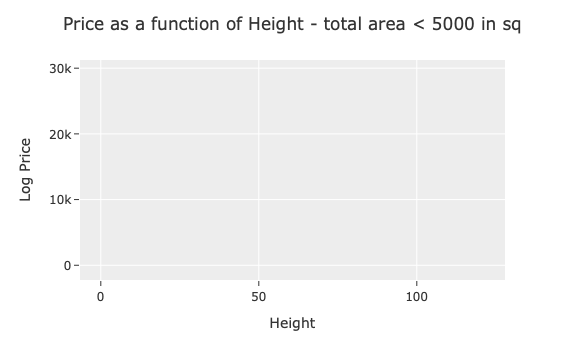

Model Score:
0.006754700790331358


In [47]:
my_columns = ['Height_in','log_price']
DF_model7 = DF_model6[my_columns]

# Do some preprocessing - drop NA and make the Surface variable a float
DF_model7.dropna(inplace=True)
DF_model7['Height_in'] = DF_model7['Height_in'].apply(lambda x: float(x))

# Mask the data for surface area less than 10,000
mask = DF_model7['Height_in'] <= 10_000
DF_model7 = DF_model6[mask]

# Make a Scatter plot
fig = px.scatter(DF_model7,
                 x='Height_in',
                 y='price',
                 color_discrete_sequence=['black'],
                 opacity=0.2,
                 trendline='ols')

fig.update_layout(template="ggplot2",
                  title='Price as a function of Height - total area < 5000 in sq',
                  title_x=0.5,
                  xaxis_title='Height',
                  yaxis_title='Log Price')


fig.show()

# Create the X and y variables for Linear Regression
X = DF_model7['Height_in'].values.reshape(-1,1)
y = DF_model7['log_price'].values

# Create linear regression object - a random straight line
LM = LinearRegression()
# Train the model using the data
LM.fit(X, y)
px.scatter(DF_model7,x='log_price_predicted',y='residual4')
# The score from my model
print('Model Score:')
print(LM.score(X,y))

with this model score the height basically explains nine of the variation in price because this model score is even lower

the log vs not log residule graphs are much different because the log helps by reducing the skewness and creating a cleaner and more liner relationship